In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/shimnet_workshop

!pip uninstall -y torchtune
!pip install -r requirements-colab.txt

# if you haven't downloaded the data yet, uncomment the line below
# !python download_files.py --all --overwrite

import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

# import from shimnet
import sys, os
sys.path.append(os.path.abspath("./src")) # add src to path
from generators import get_datapipe

def get_multiplet_info(multiplet_data):
    info_string = f"# peaks: {len(multiplet_data['tff_lin'])}"
    info_string += f"\nwidth: {multiplet_data['twf_lin'][0].item():.3f} Hz"
    info_string += f"\nGaussian fraction: {multiplet_data['trf_lin'][0].item():.3f}"
    return info_string

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/shimnet_workshop
Downloaded /content/drive/MyDrive/shimnet_workshop/weights/shimnet_700MHz.pt
Downloaded /content/drive/MyDrive/shimnet_workshop/weights/shimnet_600MHz.pt
Downloaded /content/drive/MyDrive/shimnet_workshop/data/scrf_61_700MHz.pt
Downloaded /content/drive/MyDrive/shimnet_workshop/data/scrf_81_600MHz.pt
Downloaded /content/drive/MyDrive/shimnet_workshop/data/multiplets_10000_parsed.txt


In [ ]:
config_path = "./configs/shimnet_600.yaml"
config = OmegaConf.load(config_path)
data_config = config.data
print(OmegaConf.to_yaml(data_config))


response_functions_files:
- data/scrf_81_600MHz.pt
atom_groups_data_file: data/multiplets_10000_parsed.txt
response_function_stretch_min: 1.0
response_function_stretch_max: 1.0
response_function_noise: 0.0
multiplicity_j1_min: 0.0
multiplicity_j1_max: 15
multiplicity_j2_min: 0.0
multiplicity_j2_max: 15
number_of_signals_min: 2
number_of_signals_max: 5
thf_min: 0.5
thf_max: 2
relative_height_min: 0.5
relative_height_max: 4
frq_step: 0.30048



In [3]:
pixels = data_config.get("pixels", 2048)  # 2048 is the default value
frequencies = torch.arange(-pixels // 2, pixels // 2) * data_config.frq_step

In [47]:
batch_size = 10
data_pipe = get_datapipe(**data_config, batch_size=batch_size, include_response_function=True, include_spectrum_data=True)
batch = next(iter(data_pipe))
#print(batch)
print(batch.keys())

dict_keys(['response_function', 'theoretical_spectrum', 'noised_spectrum', 'disturbed_spectrum', 'theoretical_spectrum_data'])


Text(0.5, 1.0, 'response function')

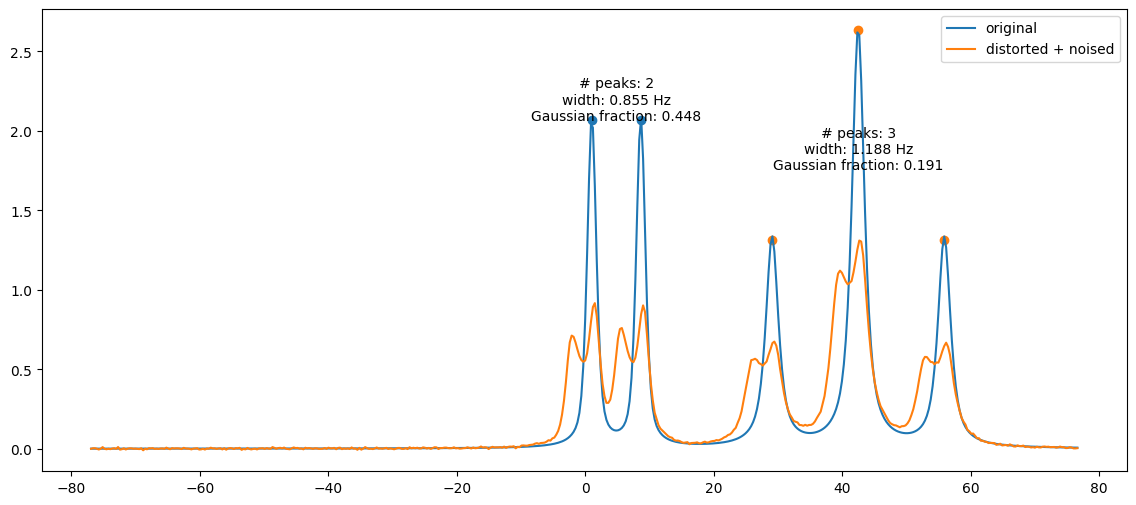

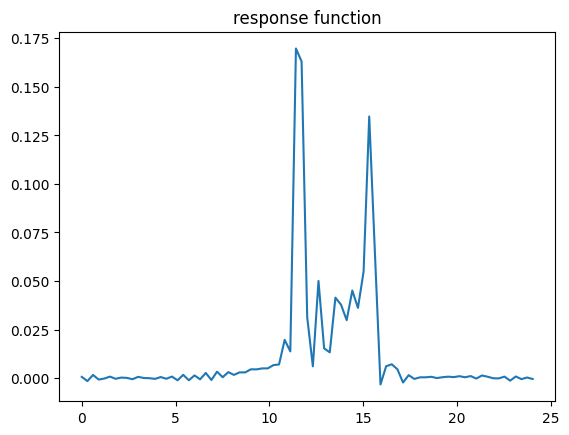

In [51]:
spectrum_index = 5
original_spectrum = batch['theoretical_spectrum'][spectrum_index][0].numpy()
distorted_spectrum = batch['disturbed_spectrum'][spectrum_index][0].numpy()
distorted_and_noised_spectrum = batch['noised_spectrum'][spectrum_index][0].numpy()
response_function = batch['response_function'][spectrum_index][0,0].numpy()
spectrum_data = batch['theoretical_spectrum_data'][spectrum_index]

plt.figure(figsize=(14, 6))
plt.plot(frequencies, original_spectrum, label='original')
plt.plot(frequencies, distorted_and_noised_spectrum, label='distorted + noised')
# optionally: plot peaks
for multiplet_data in spectrum_data:
    plt.scatter(multiplet_data["tff_lin"], multiplet_data["thf_lin"])
    multiplet_center_frq = multiplet_data['tff_lin'].mean().item()
    plt.text(multiplet_center_frq, multiplet_data['thf_lin'].mean().item(), get_multiplet_info(multiplet_data), horizontalalignment='center')
plt.legend()
#plt.xlim(150,210)

plt.figure()
plt.plot(np.arange(len(response_function))*data_config.frq_step, response_function)
plt.title("response function")



## Custom config

We will use only `data` field

In [ ]:
# data paths are already modified
yaml_config = """
data:
  response_functions_files:
  # Paste path to your SCRF file here
  # - Can be absolute path
  # - Can be relative to repository root
  - data/scrf_81_600MHz.pt
  atom_groups_data_file: data/multiplets_10000_parsed.txt
  # number of points in the spectrum
  pixels: 512
  # frequency step size [Hz]
  frq_step: 0.30048
  # range of the spectrum where multiplets are located (relative)
  relative_frequency_min: -0.4
  relative_frequency_max: 0.4
  # number of multiplets in the spectrum
  number_of_signals_min: 1
  number_of_signals_max: 3
  # spectrum height component range:
  thf_min: 4
  thf_max: 4
  # multiplet height component range:
  relative_height_min: 1
  relative_height_max: 1
  # spectrum width component range [Hz]:
  spectrum_width_min: 0.2
  spectrum_width_max: 1
  # multiplet width component range:
  relative_width_min: 1
  relative_width_max: 2
  # Gaussian fraction in multiplet shape:
  trf_min: 0
  trf_max: 1
  # multiplet spacing
  multiplicity_j1_min: 0.0
  multiplicity_j1_max: 15
  multiplicity_j2_min: 0.0
  multiplicity_j2_max: 15
  # Gaussian noise
  spectrum_noise_min: 0.
  spectrum_noise_max: 0.005
"""

config = OmegaConf.create(yaml_config)
data_config = config.data

In [68]:
# get batch
batch_size = 10
data_pipe = get_datapipe(**data_config, batch_size=batch_size, include_response_function=True, include_spectrum_data=True)
batch = next(iter(data_pipe))

# get frequencies
pixels = data_config.get("pixels", 2048)  # 2048 is the default value
frequencies = torch.arange(-pixels // 2, pixels // 2) * data_config.frq_step


Text(0.5, 1.0, 'response function')

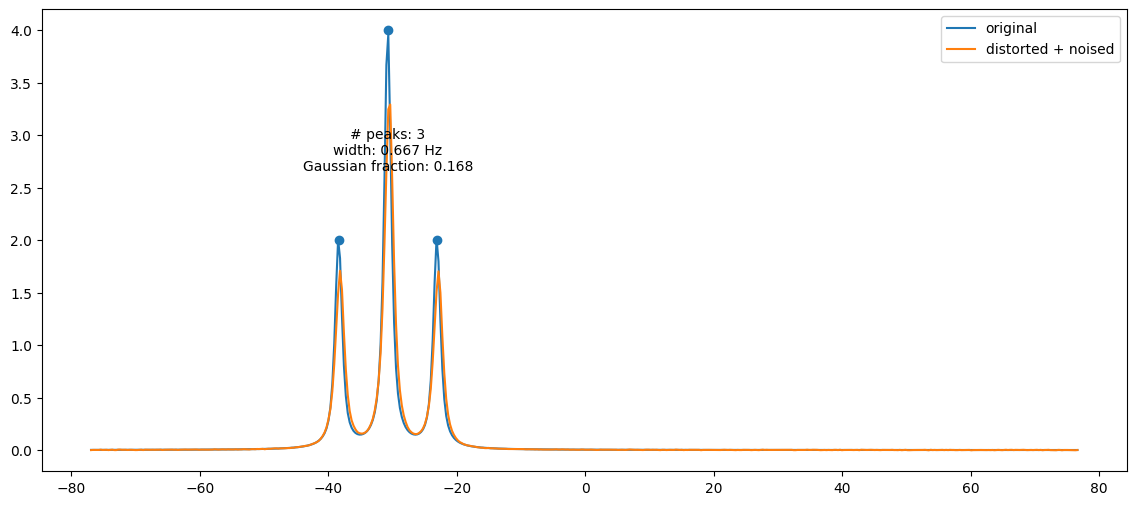

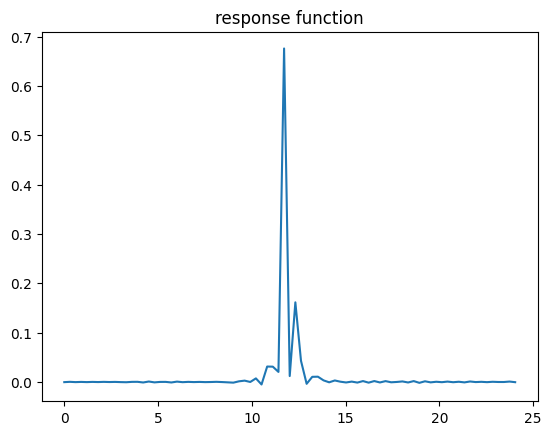

In [69]:
spectrum_index = 6
original_spectrum = batch['theoretical_spectrum'][spectrum_index][0].numpy()
distorted_spectrum = batch['disturbed_spectrum'][spectrum_index][0].numpy()
distorted_and_noised_spectrum = batch['noised_spectrum'][spectrum_index][0].numpy()
response_function = batch['response_function'][spectrum_index][0,0].numpy()
spectrum_data = batch['theoretical_spectrum_data'][spectrum_index]

plt.figure(figsize=(14, 6))
plt.plot(frequencies, original_spectrum, label='original')
plt.plot(frequencies, distorted_and_noised_spectrum, label='distorted + noised')
# optionally: plot peaks
for multiplet_data in spectrum_data:
    plt.scatter(multiplet_data["tff_lin"], multiplet_data["thf_lin"])
    multiplet_center_frq = multiplet_data['tff_lin'].mean().item()
    plt.text(multiplet_center_frq, multiplet_data['thf_lin'].mean().item(), get_multiplet_info(multiplet_data), horizontalalignment='center')
plt.legend()

plt.figure()
plt.plot(np.arange(len(response_function))*data_config.frq_step, response_function)
plt.title("response function")



### Other multiplets files

#### singlets

In [ ]:
# data paths are already modified
yaml_config = """
data:
  response_functions_files:
  # Paste path to your SCRF file here
  # - Can be absolute path
  # - Can be relative to repository root
  - data/scrf_81_600MHz.pt
  atom_groups_data_file: data/singlets.txt
  # number of points in the spectrum
  pixels: 512
  # frequency step size [Hz]
  frq_step: 0.30048
  # range of the spectrum where multiplets are located (relative)
  relative_frequency_min: -0.4
  relative_frequency_max: 0.4
  # number of multiplets in the spectrum
  number_of_signals_min: 1
  number_of_signals_max: 3
  # spectrum height component range:
  thf_min: 4
  thf_max: 4
  # multiplet height component range:
  relative_height_min: 0.5
  relative_height_max: 2
  # spectrum width component range [Hz]:
  spectrum_width_min: 0.2
  spectrum_width_max: 1
  # multiplet width component range:
  relative_width_min: 1
  relative_width_max: 2
  # Gaussian fraction in multiplet shape:
  trf_min: 0
  trf_max: 1
  # Gaussian noise
  spectrum_noise_min: 0.
  spectrum_noise_max: 0.005
"""

config = OmegaConf.create(yaml_config)
data_config = config.data

In [58]:
# get batch
batch_size = 10
data_pipe = get_datapipe(**data_config, batch_size=batch_size, include_response_function=True, include_spectrum_data=True)
batch = next(iter(data_pipe))

# get frequencies
pixels = data_config.get("pixels", 2048)  # 2048 is the default value
frequencies = torch.arange(-pixels // 2, pixels // 2) * data_config.frq_step


Text(0.5, 1.0, 'response function')

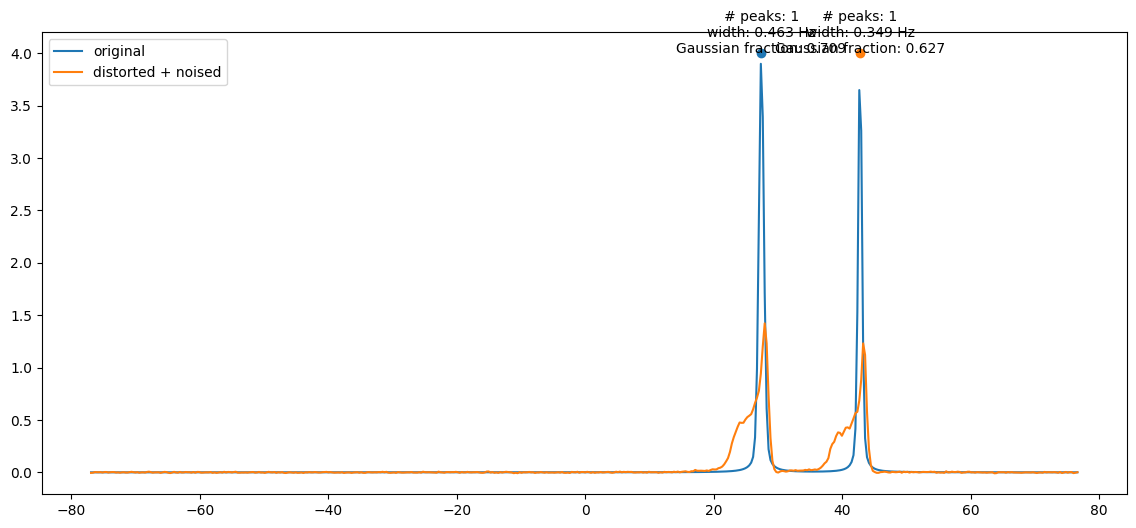

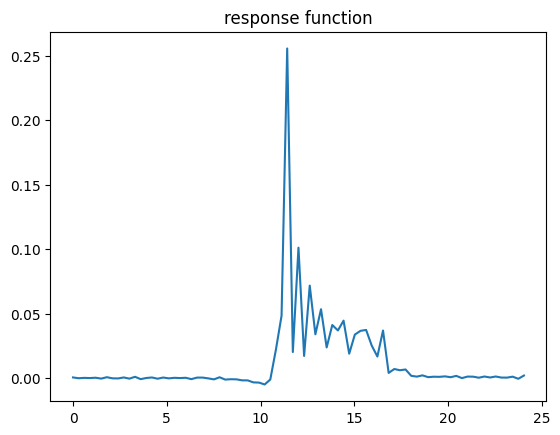

In [59]:
spectrum_index = 5
original_spectrum = batch['theoretical_spectrum'][spectrum_index][0].numpy()
distorted_spectrum = batch['disturbed_spectrum'][spectrum_index][0].numpy()
distorted_and_noised_spectrum = batch['noised_spectrum'][spectrum_index][0].numpy()
response_function = batch['response_function'][spectrum_index][0,0].numpy()
spectrum_data = batch['theoretical_spectrum_data'][spectrum_index]

plt.figure(figsize=(14, 6))
plt.plot(frequencies, original_spectrum, label='original')
plt.plot(frequencies, distorted_and_noised_spectrum, label='distorted + noised')
# optionally: plot peaks
for multiplet_data in spectrum_data:
    plt.scatter(multiplet_data["tff_lin"], multiplet_data["thf_lin"])
    multiplet_center_frq = multiplet_data['tff_lin'].mean().item()
    plt.text(multiplet_center_frq, multiplet_data['thf_lin'].mean().item(), get_multiplet_info(multiplet_data), horizontalalignment='center')
plt.legend()

plt.figure()
plt.plot(np.arange(len(response_function))*data_config.frq_step, response_function)
plt.title("response function")



#### singlets-doublets-triplets

In [ ]:
# data paths are already modified
yaml_config = """
data:
  response_functions_files:
  # Paste path to your SCRF file here
  # - Can be absolute path
  # - Can be relative to repository root
  - ./data/scrf_81_600MHz.pt
  atom_groups_data_file: ./data/singlets_doublets_triplets.txt
  # number of points in the spectrum
  pixels: 512
  # frequency step size [Hz]
  frq_step: 0.30048
  # range of the spectrum where multiplets are located (relative)
  relative_frequency_min: -0.4
  relative_frequency_max: 0.4
  # number of multiplets in the spectrum
  number_of_signals_min: 1
  number_of_signals_max: 3
  # spectrum height component range:
  thf_min: 4
  thf_max: 4
  # multiplet height component range:
  relative_height_min: 0.5
  relative_height_max: 2
  # spectrum width component range [Hz]:
  spectrum_width_min: 0.2
  spectrum_width_max: 1
  # multiplet width component range:
  relative_width_min: 1
  relative_width_max: 2
  # Gaussian fraction in multiplet shape:
  trf_min: 0
  trf_max: 1
  # Gaussian noise
  spectrum_noise_min: 0.
  spectrum_noise_max: 0.005
"""

config = OmegaConf.create(yaml_config)
data_config = config.data

In [71]:
# get batch
batch_size = 10
data_pipe = get_datapipe(**data_config, batch_size=batch_size, include_response_function=True, include_spectrum_data=True)
batch = next(iter(data_pipe))

# get frequencies
pixels = data_config.get("pixels", 2048)  # 2048 is the default value
frequencies = torch.arange(-pixels // 2, pixels // 2) * data_config.frq_step


Text(0.5, 1.0, 'response function')

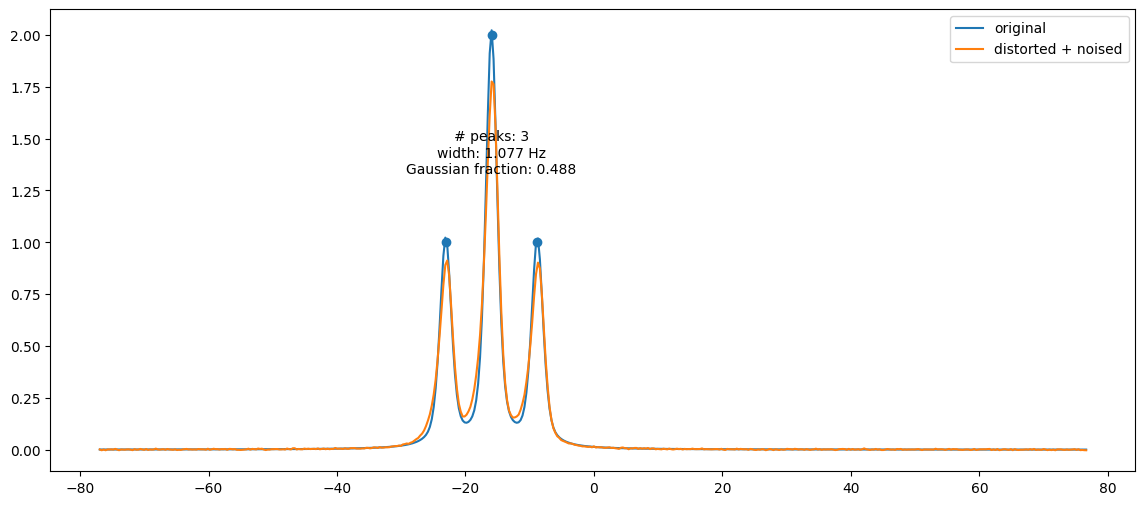

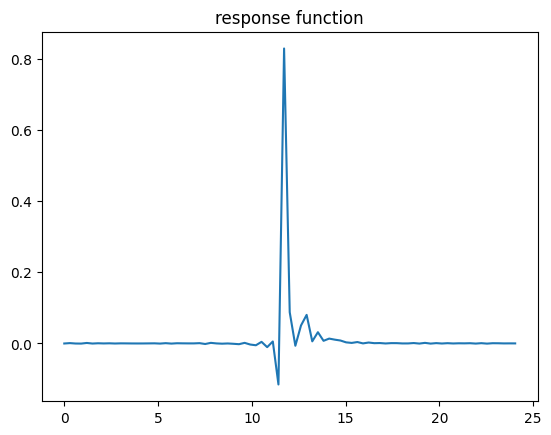

In [76]:
spectrum_index = 8
original_spectrum = batch['theoretical_spectrum'][spectrum_index][0].numpy()
distorted_spectrum = batch['disturbed_spectrum'][spectrum_index][0].numpy()
distorted_and_noised_spectrum = batch['noised_spectrum'][spectrum_index][0].numpy()
response_function = batch['response_function'][spectrum_index][0,0].numpy()
spectrum_data = batch['theoretical_spectrum_data'][spectrum_index]

plt.figure(figsize=(14, 6))
plt.plot(frequencies, original_spectrum, label='original')
plt.plot(frequencies, distorted_and_noised_spectrum, label='distorted + noised')
# optionally: plot peaks
for multiplet_data in spectrum_data:
    plt.scatter(multiplet_data["tff_lin"], multiplet_data["thf_lin"])
    multiplet_center_frq = multiplet_data['tff_lin'].mean().item()
    plt.text(multiplet_center_frq, multiplet_data['thf_lin'].mean().item(), get_multiplet_info(multiplet_data), horizontalalignment='center')
plt.legend()

plt.figure()
plt.plot(np.arange(len(response_function))*data_config.frq_step, response_function)
plt.title("response function")

